# Exercise 3
## Your task:
Create a *Graph* where you sequentially process name, age and skills.

*Input:* `{"name": "Gerald", "age": 233, "skills": ["Ham", "Cheese", "Gogurt"]}`
<br>
*Output:* `"So your name's Gerald, huh? I can see that you're 233 years old in the file. You also have skills in Ham, Cheese, and Gogurt. Pretty nice!"`

In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import math

In [2]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    message: str

In [3]:
def first_node(state: AgentState) -> AgentState:
    """First node in sequende: Greeting with name"""

    state['message'] = f"So your name's {state['name']}, huh?"

    return state

def second_node(state: AgentState) -> AgentState:
    """Second node in sequende: Acknowledge age and add to message"""

    state['message'] += f" I can see that you're {state['age']} years old in the file."

    return state

def third_node(state: AgentState) -> AgentState:
    """third node in sequende: List skills in message and end with a nice compliment"""

    if len(state['skills']) == 0:
        state['message'] += f" You don't have any skills? That's motivation for improvement!"
    elif len(state['skills']) == 1:
        state['message'] += f" You're also skilled in {state['skills'][0]}. Pretty nice!"
    elif len(state['skills']) == 2:
        state['message'] += f" You're also skilled in {state['skills'][0]} and {state['skills'][1]}. Pretty nice!"
    else:
        state['message'] += f" You're also skilled in "
        for skill in state['skills'][:-1]:
            state['message'] += f"{skill}, " 
        state['message'] += f"and {state['skills'][-1]}. Pretty nice!"

    return state

In [4]:
graph = StateGraph(AgentState)

graph.add_node('first', first_node)
graph.add_node('second', second_node)
graph.add_node('third', third_node)

graph.set_entry_point('first')
graph.add_edge('first', 'second')
graph.add_edge('second', 'third')
graph.set_finish_point('third')

app = graph.compile()

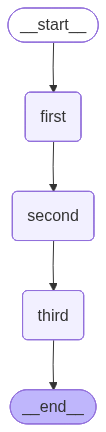

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
answer = app.invoke({'skills': ["Ham", "Cheese", "Gogurt"], 'name': 'Gerald', 'age': 33.35})
print(answer)

{'name': 'Gerald', 'age': 33.35, 'skills': ['Ham', 'Cheese', 'Gogurt'], 'message': "So your name's Gerald, huh? I can see that you're 33.35 years old in the file. You're also skilled in Ham, Cheese, and Gogurt. Pretty nice!"}


In [7]:
print(answer['message'])

So your name's Gerald, huh? I can see that you're 33.35 years old in the file. You're also skilled in Ham, Cheese, and Gogurt. Pretty nice!


In [9]:
answer = app.invoke({'skills': ["Ham", "Cheese"], 'name': 'Gerald', 'age': 33.35})
print(answer['message'])

So your name's Gerald, huh? I can see that you're 33.35 years old in the file. You're also skilled in Ham and Cheese. Pretty nice!


In [10]:
answer = app.invoke({'skills': ["Ham"], 'name': 'Gerald', 'age': 33.35})
print(answer['message'])

So your name's Gerald, huh? I can see that you're 33.35 years old in the file. You're also skilled in Ham. Pretty nice!


In [11]:
answer = app.invoke({'skills': [], 'name': 'Gerald', 'age': 33.35})
print(answer['message'])

So your name's Gerald, huh? I can see that you're 33.35 years old in the file. You don't have any skills? That's motivation for improvement!
